# 03 — Baseline Models (Member 2: Model Engineer)
Logistic Regression is the performance floor. If a deep model cannot beat a
linear one, the problem is the setup rather than the architecture.

XGBoost is the serious baseline. Gradient boosting is the reigning default
on tabular data, so RQ1 — *do deep tabular models outperform gradient
boosting?* — is only meaningful if XGBoost is properly tuned rather than left
at library defaults.

Protocol. Hyperparameters are searched with Optuna on the validation
fold. The test fold is touched once, at the end. Each configuration is retrained
across five seeds and reported as mean ± std, because measured run-to-run noise
on this dataset is ≈0.007 F1-macro — any gap smaller than ≈0.015 is
indistinguishable from chance.

In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

import config as C
from data_prep import load_prepared
from evaluation import evaluate, print_report, class_weights, aggregate_seeds
from train_baselines import (train_logistic, tune_xgboost, train_xgboost)

sns.set_theme(style="whitegrid")
Xtr, ytr, Xva, yva, Xte, yte, meta = load_prepared()
print(f"train {Xtr.shape} | val {Xva.shape} | test {Xte.shape}")
print(f"classes: {list(meta['label_encoder'].classes_)}")

train (6396, 23) | val (1383, 23) | test (1379, 23)
classes: [np.str_('At-Risk'), np.str_('Distressed'), np.str_('Healthy')]


In [2]:
# 1. Why F1-macro rather than accuracy

counts = np.bincount(ytr)
w = class_weights(ytr)
print(pd.DataFrame({"class": meta["label_encoder"].classes_,
                    "train_count": counts,
                    "share_%": (counts / counts.sum() * 100).round(1),
                    "loss_weight": w.round(3)}).to_string(index=False))

naive = np.full_like(yte, counts.argmax())
m = evaluate(yte, naive)
print(f"\nMajority-class baseline: accuracy={m['accuracy']:.3f}  "
      f"F1-macro={m['f1_macro']:.3f}")

     class  train_count  share_%  loss_weight
   At-Risk         2585     40.4        0.825
Distressed         2870     44.9        0.743
   Healthy          941     14.7        2.266

Majority-class baseline: accuracy=0.448  F1-macro=0.206


In [3]:
# 2. Logistic Regression — the floor
lr_model, lr_scaler, lr_res, lr_secs, lr_params = train_logistic(
    Xtr, ytr, Xva, yva, Xte, yte, seed=C.PRIMARY_SEED)

print(f"val  F1-macro = {lr_res['val']['f1_macro']:.4f}")
print(f"test F1-macro = {lr_res['test']['f1_macro']:.4f}")
print(f"trained in {lr_secs:.2f}s, {lr_params} parameters")
print_report(yte, lr_model.predict(lr_scaler.transform(Xte)),
             "Logistic Regression — test set")

val  F1-macro = 0.7401
test F1-macro = 0.7370
trained in 0.37s, 72 parameters

Logistic Regression — test set
------------------------------
              precision    recall  f1-score   support

     At-Risk      0.794     0.655     0.718       566
  Distressed      0.875     0.835     0.854       618
     Healthy      0.512     0.846     0.638       195

    accuracy                          0.763      1379
   macro avg      0.727     0.779     0.737      1379
weighted avg      0.790     0.763     0.768      1379

Confusion matrix (rows = true, cols = predicted)
            At-Risk  Distressed  Healthy
At-Risk         371          69      126
Distressed       71         516       31
Healthy          25           5      165


In [4]:
# 3. XGBoost — tuned baseline

best_params, best_val = tune_xgboost(Xtr, ytr, Xva, yva,
                                     n_trials=C.N_TRIALS_XGB,
                                     seed=C.PRIMARY_SEED)
print(f"best validation F1-macro = {best_val:.4f}\n")
print(json.dumps(best_params, indent=2))

best validation F1-macro = 0.8616

{
  "n_estimators": 300,
  "max_depth": 6,
  "learning_rate": 0.031149459862852148,
  "subsample": 0.8045451640448885,
  "colsample_bytree": 0.8618800629654775,
  "min_child_weight": 10,
  "reg_lambda": 0.8050011789113894,
  "reg_alpha": 0.0008520430922053558
}


In [5]:
rows = []
for seed in C.MODEL_SEEDS:
    model, res, secs, npar = train_xgboost(Xtr, ytr, Xva, yva, Xte, yte,
                                           best_params, seed=seed)
    rows.append({"seed": seed,
                 "val_f1": res["val"]["f1_macro"],
                 "test_f1": res["test"]["f1_macro"],
                 "healthy_f1": res["test"]["f1_healthy"],
                 "seconds": round(secs, 2)})

seed_df = pd.DataFrame(rows)
print(seed_df.to_string(index=False))
print(f"\ntest F1-macro = {seed_df.test_f1.mean():.4f} ± {seed_df.test_f1.std():.4f}")

 seed   val_f1  test_f1  healthy_f1  seconds
   42 0.861614 0.847318    0.808314     1.07
    7 0.852855 0.847750    0.812933     0.91
  123 0.855293 0.848870    0.815668     0.93
 2024 0.858604 0.846661    0.805556     0.87
  999 0.850495 0.846014    0.807425     0.87

test F1-macro = 0.8473 ± 0.0011


In [6]:
print_report(yte, model.predict(Xte), "XGBoost — test set")


XGBoost — test set
------------------
              precision    recall  f1-score   support

     At-Risk      0.839     0.829     0.834       566
  Distressed      0.923     0.872     0.897       618
     Healthy      0.737     0.892     0.807       195

    accuracy                          0.857      1379
   macro avg      0.833     0.864     0.846      1379
weighted avg      0.862     0.857     0.858      1379

Confusion matrix (rows = true, cols = predicted)
            At-Risk  Distressed  Healthy
At-Risk         469          45       52
Distressed       69         539       10
Healthy          21           0      174


## 4. Circularity audit

The labels derive from Altman Z′, which is exactly reconstructible from the raw
columns. The exact components were excluded from the feature set, but that
decision needs verifying rather than asserting.

If any single feature carried most of the gain, it would suggest the model had
found a proxy for the label rather than learning the task. A well-distributed
importance profile is the evidence that the exclusion worked.

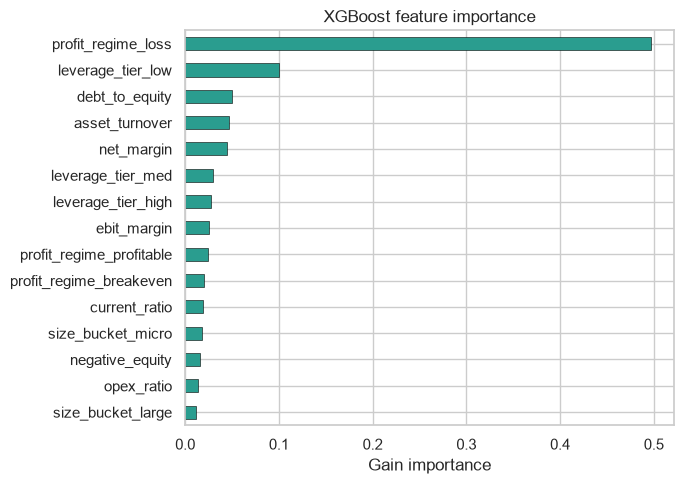

top feature 'profit_regime_loss' carries 49.7% of total gain
PASS — no single feature dominates


In [7]:
## 4. Circularity audit

imp = pd.Series(model.feature_importances_,
                index=Xtr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15)[::-1].plot.barh(ax=ax, color="#2a9d8f", edgecolor="black", linewidth=.4)
ax.set_xlabel("Gain importance")
ax.set_title("XGBoost feature importance")
plt.tight_layout(); plt.show()

share = imp.iloc[0] * 100
print(f"top feature '{imp.index[0]}' carries {share:.1f}% of total gain")
print("PASS — no single feature dominates" if share < 60
      else "WARNING — possible label proxy")

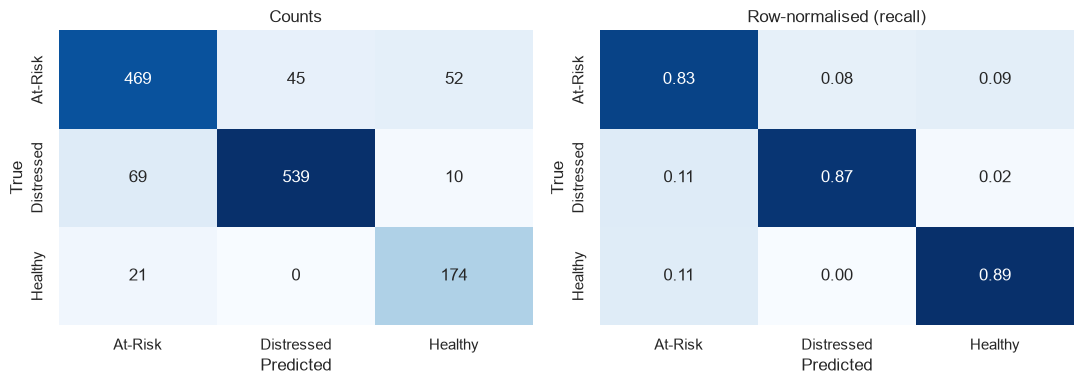

In [8]:
## 5. Where the errors fall

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(yte, model.predict(Xte))
cls = meta["label_encoder"].classes_

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (mat, title, fmt) in zip(axes, [
        (cm, "Counts", "d"),
        (cm / cm.sum(axis=1, keepdims=True), "Row-normalised (recall)", ".2f")]):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues", ax=ax,
                xticklabels=cls, yticklabels=cls, cbar=False)
    ax.set(title=title, xlabel="Predicted", ylabel="True")
plt.tight_layout(); plt.show()

## Summary

| Model | Role | Expected F1-macro |
|---|---|---|
| Majority class | sanity floor | ≈0.21 |
| Logistic Regression | linear floor | ≈0.74 |
| XGBoost | tuned baseline to beat | ≈0.85 |